In [10]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [11]:
base_dir = "all_datasets_consensus/anal_pc5_c21_S1.filtered_consensus_outputs" 
k_start  = 5
k_end    = 15
corr_method = "pearson"  
min_corr_to_link = None  # e.g. 0.2 to drop weak links; None keeps all

# If best parent correlation is below this threshold, show top N parents instead
strong_corr_threshold = 0.9
top_n_parents_for_weak = 3  # number of parents to show for weak children

file_glob_template = "*gene_spectra_score*k_{k}*"

In [12]:
def find_file_for_k(base_dir: str, k: int, glob_template: str) -> str:
    patt = os.path.join(base_dir, glob_template.format(k=k))
    hits = sorted(glob.glob(patt))

    if len(hits) == 0:
        raise FileNotFoundError(
            f"No gene_spectra_score file found for k={k}\nPattern tried: {patt}"
        )

    if len(hits) > 1:
        print(f"⚠️ Multiple gene_spectra_score files found for k={k}. Using first:")
        for h in hits:
            print("   ", os.path.basename(h))

    return hits[0]

In [13]:
def load_gene_spectra_scores(filepath: str) -> pd.DataFrame:
    """
    Expected format (like your example):
      - TSV
      - header row = gene names
      - first column = program id (1..K), possibly with a blank header
      - rows = programs, columns = genes
    Returns: DataFrame indexed by program id, columns = genes (float)
    """
    df = pd.read_csv(filepath, sep="\t", header=0, index_col=0)
    # Ensure numeric
    df = df.apply(pd.to_numeric, errors="coerce")
    # Drop any fully-empty columns
    df = df.dropna(axis=1, how="all")
    return df

In [14]:
Ks = list(range(k_start, k_end + 1))

k_to_path = {}
k_to_df_raw = {}

for k in Ks:
    path = find_file_for_k(base_dir, k, file_glob_template)
    k_to_path[k] = path
    k_to_df_raw[k] = load_gene_spectra_scores(path)

print("Loaded files:")
for k in Ks:
    print(f"  K={k}: {os.path.basename(k_to_path[k])}  shape={k_to_df_raw[k].shape}")

# Align genes across ALL K (intersection)
common_genes = set(k_to_df_raw[Ks[0]].columns)
for k in Ks[1:]:
    common_genes &= set(k_to_df_raw[k].columns)
common_genes = sorted(common_genes)

if len(common_genes) == 0:
    raise ValueError("No common genes across all K files. Check that columns are consistent.")

k_to_df = {k: k_to_df_raw[k][common_genes].copy() for k in Ks}

print(f"\nCommon genes across K={k_start}..{k_end}: {len(common_genes)}")

Loaded files:
  K=5: anal_pc5_c21_S1.filtered.gene_spectra_score.k_5.dt_0_01.txt  shape=(5, 5000)
  K=6: anal_pc5_c21_S1.filtered.gene_spectra_score.k_6.dt_0_01.txt  shape=(6, 5000)
  K=7: anal_pc5_c21_S1.filtered.gene_spectra_score.k_7.dt_0_01.txt  shape=(7, 5000)
  K=8: anal_pc5_c21_S1.filtered.gene_spectra_score.k_8.dt_0_01.txt  shape=(8, 5000)
  K=9: anal_pc5_c21_S1.filtered.gene_spectra_score.k_9.dt_0_01.txt  shape=(9, 5000)
  K=10: anal_pc5_c21_S1.filtered.gene_spectra_score.k_10.dt_0_01.txt  shape=(10, 5000)
  K=11: anal_pc5_c21_S1.filtered.gene_spectra_score.k_11.dt_0_01.txt  shape=(11, 5000)
  K=12: anal_pc5_c21_S1.filtered.gene_spectra_score.k_12.dt_0_01.txt  shape=(12, 5000)
  K=13: anal_pc5_c21_S1.filtered.gene_spectra_score.k_13.dt_0_01.txt  shape=(13, 5000)
  K=14: anal_pc5_c21_S1.filtered.gene_spectra_score.k_14.dt_0_01.txt  shape=(14, 5000)
  K=15: anal_pc5_c21_S1.filtered.gene_spectra_score.k_15.dt_0_01.txt  shape=(15, 5000)

Common genes across K=5..15: 5000


In [15]:
def rowwise_pearson(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """
    Correlation between each row of A (nA x G) and each row of B (nB x G).
    Returns: (nA x nB) matrix.
    """
    # Center
    A0 = A - A.mean(axis=1, keepdims=True)
    B0 = B - B.mean(axis=1, keepdims=True)
    # Normalize
    A_norm = np.linalg.norm(A0, axis=1, keepdims=True)
    B_norm = np.linalg.norm(B0, axis=1, keepdims=True)
    A_norm[A_norm == 0] = np.nan
    B_norm[B_norm == 0] = np.nan
    # Corr = dot / (||a|| ||b||)
    return (A0 @ B0.T) / (A_norm @ B_norm.T)


def rank_rows(X: np.ndarray) -> np.ndarray:
    """
    Rank-transform each row (Spearman). Ties get average rank via pandas.
    """
    # Using pandas for tie-aware ranking per row
    return pd.DataFrame(X).rank(axis=1, method="average").to_numpy()


def rowwise_corr(A: np.ndarray, B: np.ndarray, method: str) -> np.ndarray:
    method = method.lower()
    if method == "pearson":
        return rowwise_pearson(A, B)
    elif method == "spearman":
        Ar = rank_rows(A)
        Br = rank_rows(B)
        return rowwise_pearson(Ar, Br)
    else:
        raise ValueError("corr_method must be 'pearson' or 'spearman'")

In [16]:
edges = []  # list of dicts

for k in range(k_start, k_end):
    df_parent = k_to_df[k]
    df_child  = k_to_df[k + 1]

    A = df_parent.to_numpy()
    B = df_child.to_numpy()

    C = rowwise_corr(A, B, corr_method)  # shape: (K x K+1)

    # Build labels
    parent_ids = df_parent.index.tolist()   # typically 1..K
    child_ids  = df_child.index.tolist()    # typically 1..K+1

    # For each child, find best parent(s)
    for j, child_id in enumerate(child_ids):
        col = C[:, j]
        if np.all(np.isnan(col)):
            continue
        
        # Get sorted indices by correlation (descending)
        sorted_indices = np.argsort(col)[::-1]
        best_corr = float(col[sorted_indices[0]])
        
        # Determine how many parents to link
        if best_corr >= strong_corr_threshold:
            # Strong match: just link to best parent
            n_parents = 1
        else:
            # Weak match: link to top N parents
            n_parents = min(top_n_parents_for_weak, len(parent_ids))
        
        # Add edges for top N parents
        for rank in range(n_parents):
            parent_idx = sorted_indices[rank]
            corr_val = float(col[parent_idx])
            
            # Skip if below minimum threshold
            if min_corr_to_link is not None and corr_val < min_corr_to_link:
                continue
            
            # Skip NaN correlations
            if np.isnan(corr_val):
                continue
            
            parent_id = parent_ids[parent_idx]
            
            edges.append({
                "k_parent": k,
                "parent": f"K{k}_P{parent_id}",
                "k_child": k + 1,
                "child": f"K{k+1}_P{child_id}",
                "corr": corr_val,
                "is_best": rank == 0  # flag to identify primary vs secondary edges
            })

edges_df = pd.DataFrame(edges).sort_values(["k_parent", "child", "corr"], ascending=[True, True, False]).reset_index(drop=True)
print(f"Total edges: {len(edges_df)}")
print(f"Primary edges (best match): {edges_df['is_best'].sum()}")
print(f"Secondary edges (for weak children): {(~edges_df['is_best']).sum()}")
edges_df.head(15)

Total edges: 137
Primary edges (best match): 105
Secondary edges (for weak children): 32


,k_parent,parent,k_child,child,corr,is_best
0,5,K5_P1,6,K6_P1,0.999945,True
1,5,K5_P2,6,K6_P2,0.991402,True
2,5,K5_P3,6,K6_P3,0.998564,True
3,5,K5_P4,6,K6_P4,0.999839,True
4,5,K5_P5,6,K6_P5,0.999984,True
5,5,K5_P2,6,K6_P6,0.134931,True
6,5,K5_P3,6,K6_P6,0.063034,False
7,5,K5_P5,6,K6_P6,-0.020019,False
8,6,K6_P2,7,K7_P1,0.998187,True
9,6,K6_P1,7,K7_P2,0.945467,True


In [17]:
edges_df.groupby("k_parent")["corr"].agg(["count", "mean", "median", "min", "max"]).reset_index()

,k_parent,count,mean,median,min,max
0,5,8,0.645960,0.994983,-0.020019,0.999984
1,6,9,0.702598,0.996707,0.011773,0.999601
2,7,10,0.737120,0.999214,0.018484,0.999887
3,8,11,0.808111,0.996310,0.100906,0.999995
4,9,14,0.665301,0.991951,-0.114187,0.999941
5,10,17,0.625676,0.808108,0.037015,0.997440
6,11,16,0.710547,0.961336,0.027441,0.998308
7,12,19,0.612571,0.966751,-0.060039,0.999954
8,13,16,0.826357,0.999667,0.062536,0.999999
9,14,17,0.848537,0.999937,0.046339,0.999997


K range: 5-15 (11 levels)
Max programs in a row: 15
Figure size: 10.5 x 8.5


/var/folders/bw/grhyggnj06ncywf0093kz3ch0000gn/T/ipykernel_16175/2250902753.py:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', k_range)  # Use tab20 for distinct colors


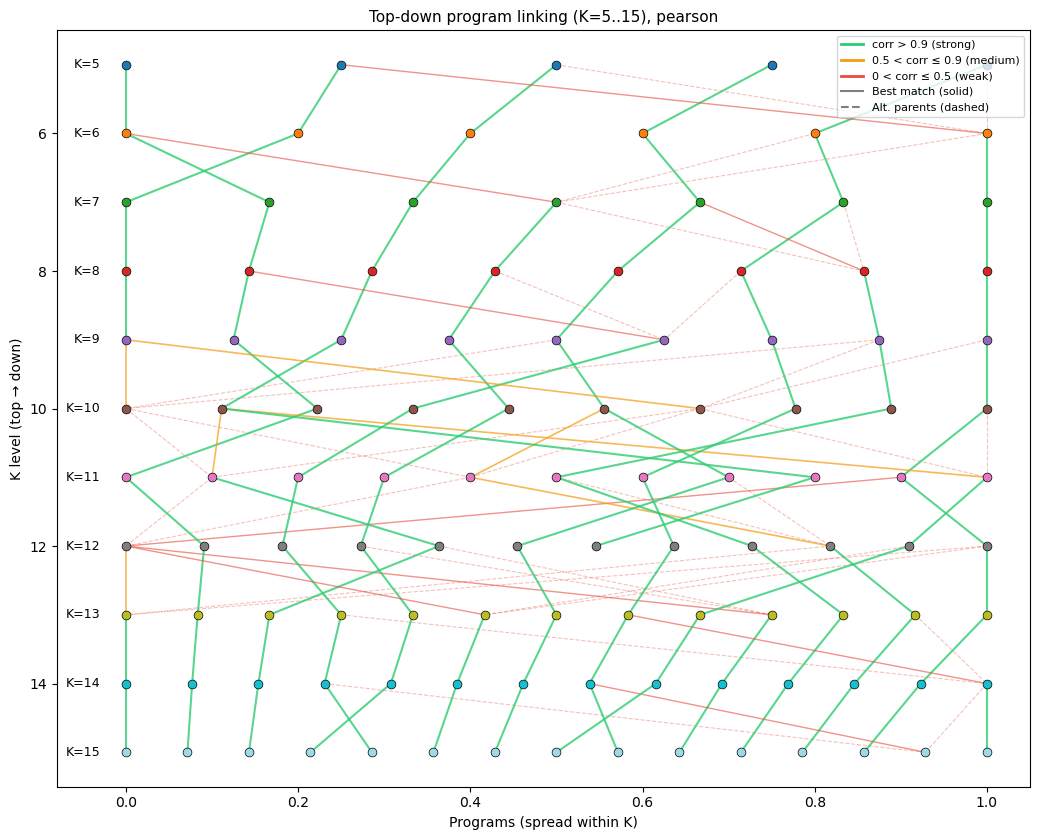

In [18]:
#   1. Edge colors based on correlation thresholds
#   2. Same color for all dots in each K row
#   3. Dynamic figure size based on K range
#   4. Secondary edges (for weak children) shown as dashed lines

# ============ CONFIGURATION ============
# Edge colors by correlation threshold
COLOR_HIGH = "#2ecc71"      # corr > 0.9 (green - strong)
COLOR_MED = "#f39c12"       # 0.5 < corr <= 0.9 (orange - medium)
COLOR_LOW = "#e74c3c"       # 0 < corr <= 0.5 (red - weak)

# ============ COLLECT NODES ============
layer_nodes = {}
for k in range(k_start, k_end + 1):
    df = k_to_df[k]
    layer_nodes[k] = [f"K{k}_P{pid}" for pid in df.index.tolist()]

# ============ ASSIGN POSITIONS ============
# y = k (layer), x = evenly spaced within that layer
pos = {}
for k, nodes in layer_nodes.items():
    x = np.linspace(0, 1, len(nodes)) if len(nodes) > 1 else np.array([0.5])
    for node, xx in zip(nodes, x):
        pos[node] = (xx, k)

# ============ DYNAMIC FIGURE SIZE ============
k_range = k_end - k_start + 1
max_programs = max(len(nodes) for nodes in layer_nodes.values())

# Scale figure size based on content
# Width: base 6 + scale by max programs (wider if more programs)
# Height: base 3 + scale by k range (taller if more K levels)
fig_width = max(6, min(16, 6 + max_programs * 0.3))
fig_height = max(4, min(14, 3 + k_range * 0.5))

print(f"K range: {k_start}-{k_end} ({k_range} levels)")
print(f"Max programs in a row: {max_programs}")
print(f"Figure size: {fig_width:.1f} x {fig_height:.1f}")

plt.figure(figsize=(fig_width, fig_height))

# ============ DRAW EDGES (colored by correlation) ============
# Draw secondary edges first (behind), then primary edges on top
for is_best_val in [False, True]:  # secondary first, then primary
    for _, r in edges_df.iterrows():
        if r["is_best"] != is_best_val:
            continue
            
        p = r["parent"]
        c = r["child"]
        corr = r["corr"]
        is_best = r["is_best"]
        
        if p in pos and c in pos:
            x1, y1 = pos[p]
            x2, y2 = pos[c]
            
            # Determine edge color based on correlation
            if corr > 0.9:
                edge_color = COLOR_HIGH
                alpha = 0.8 if is_best else 0.5
                linewidth = 1.5 if is_best else 1.0
            elif corr > 0.5:
                edge_color = COLOR_MED
                alpha = 0.7 if is_best else 0.4
                linewidth = 1.2 if is_best else 0.9
            else:  # 0 < corr <= 0.5
                edge_color = COLOR_LOW
                alpha = 0.6 if is_best else 0.35
                linewidth = 1.0 if is_best else 0.8
            
            # Secondary edges are dashed
            linestyle = '-' if is_best else '--'
            
            plt.plot([x1, x2], [y1, y2], color=edge_color, linewidth=linewidth, 
                     alpha=alpha, linestyle=linestyle)

# ============ DRAW NODES (same color per K row) ============
# Create a colormap for K levels
cmap = cm.get_cmap('tab20', k_range)  # Use tab20 for distinct colors

for idx, (k, nodes) in enumerate(layer_nodes.items()):
    xs = [pos[n][0] for n in nodes]
    ys = [pos[n][1] for n in nodes]
    node_color = cmap(idx)  # Same color for all dots in this K row
    plt.scatter(xs, ys, s=40, color=node_color, edgecolors='black', linewidths=0.5, zorder=5)
    # Label each K level on the left
    plt.text(-0.03, k, f"K={k}", ha="right", va="center", fontsize=9)

# ============ LEGEND FOR EDGE COLORS ============
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=COLOR_HIGH, linewidth=2, label='corr > 0.9 (strong)'),
    Line2D([0], [0], color=COLOR_MED, linewidth=2, label='0.5 < corr ≤ 0.9 (medium)'),
    Line2D([0], [0], color=COLOR_LOW, linewidth=2, label='0 < corr ≤ 0.5 (weak)'),
    Line2D([0], [0], color='gray', linewidth=1.5, linestyle='-', label='Best match (solid)'),
    Line2D([0], [0], color='gray', linewidth=1.5, linestyle='--', label='Alt. parents (dashed)')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=8)

plt.title(f"Top-down program linking (K={k_start}..{k_end}), {corr_method}", fontsize=11)
plt.xlabel("Programs (spread within K)")
plt.ylabel("K level (top → down)")

# Make it read top-down visually: smallest K at the top
plt.gca().invert_yaxis()

plt.xlim(-0.08, 1.05)
plt.ylim(k_end + 0.5, k_start - 0.5)  # (works nicely with invert_yaxis)
plt.tight_layout()
plt.show()